In [10]:
import os
import numpy as np
from collections import Counter
import numpy as np 
import pandas as pd
from skimage.transform import resize
from sklearn.model_selection import train_test_split

base_path = "/mnt/d/Hoc_tap_Sinh_Vien/Kien_thu_AI/Project/Duration_edge_ai/data/processed/dataMel2"

def load_mel_shapes(base_path):
    shapes_info = []
    class_counts = {} 

    for label, category in enumerate(['xanh', 'chin']):
        folder_path = os.path.join(base_path, category)

        if not os.path.exists(folder_path):
            print(f"Không tìm thấy thư mục: {folder_path}")
            continue

        files = [f for f in os.listdir(folder_path) if f.endswith('.npy')]
        class_counts[category] = len(files)
        print(f"{category} (Label {label}): {len(files)} files")

        for file in files:
            file_path = os.path.join(folder_path, file)
            try:
                # Chỉ cần đọc metadata để lấy shape (rất nhẹ RAM)
                mel_spec = np.load(file_path, mmap_mode='r')
                shapes_info.append((category, file, mel_spec.shape))
            except Exception as e:
                print(f"Lỗi {file}: {e}")

    return shapes_info, class_counts

shapes_info, class_counts = load_mel_shapes(base_path)
print(f"\nĐã kiểm tra {len(shapes_info)} ma trận mel")

# Phân phối dữ liệu (Check mất cân bằng)
print("\nPhân phối dữ liệu theo lớp:")
for cls, count in class_counts.items():
    print(f"   - {cls}: {count} files")

# Các shape khác nhau
unique_shapes = {shape for _, _, shape in shapes_info}
print(f"\nCác shape khác nhau: {unique_shapes}")

shape_counts = Counter(shape for _, _, shape in shapes_info)
print("\nPhân phối shape:")
for shape, count in shape_counts.items():
    print(f"   - {shape}: {count} files ({count / len(shapes_info) * 100:.1f}%)")


xanh (Label 0): 857 files
chin (Label 1): 275 files

Đã kiểm tra 1132 ma trận mel

Phân phối dữ liệu theo lớp:
   - xanh: 857 files
   - chin: 275 files

Các shape khác nhau: {(128, 16)}

Phân phối shape:
   - (128, 16): 1132 files (100.0%)


In [11]:
import os
import numpy as np
from sklearn.preprocessing import LabelEncoder

N_MELS = 128

class MelDataLoader:
    def __init__(self, data_dir):
        self.data_dir = data_dir
        self.label_encoder = LabelEncoder()

    def load_data(self):
        X_list = []
        y_list = []

        for label in ['xanh', 'chin']:
            folder_path = os.path.join(self.data_dir, label)
            if not os.path.isdir(folder_path):
                print(f"Không tìm thấy thư mục: {folder_path}")
                continue

            files = [f for f in os.listdir(folder_path) if f.endswith('.npy')]
            print(f"\n {label}: {len(files)} files")

            for file in files:
                file_path = os.path.join(folder_path, file)
                try:
                    data = np.load(file_path)
                    if data.ndim != 2:
                        continue
                    if data.shape[0] != N_MELS and data.shape[1] == N_MELS:
                        data = data.T
                    if data.shape[0] == N_MELS:
                        X_list.append(data)
                        y_list.append(label)

                except Exception as e:
                    print(f"Lỗi {label}/{file}: {e}")

        if not X_list:
            print("Không có dữ liệu hợp lệ!")
            return None, None

        # 1. Tìm độ dài thời gian lớn nhất
        target_time = max(x.shape[1] for x in X_list)
        print(f"\n n_mels: {N_MELS}")
        print(f"target_time: {target_time}")

        # 2. Lọc các mel không đạt yêu cầu và các nhãn tương ứng
        X_filtered = []
        y_filtered = []
        for i in range(len(X_list)):
            if X_list[i].shape[1] == target_time:
                X_filtered.append(X_list[i])
                y_filtered.append(y_list[i])

        # Cập nhật X_list và y_list với dữ liệu đã lọc
        X_list = X_filtered
        y_list = y_filtered

        if not X_list:
            print("Không có dữ liệu hợp lệ sau khi lọc theo target_time!")
            return None, None

        X = np.asarray(X_list, dtype=np.float32)
        y = self.label_encoder.fit_transform(y_list)
        print(f"Mapping nhãn: {dict(zip(self.label_encoder.classes_, self.label_encoder.transform(self.label_encoder.classes_)))}")

        X = (X - np.min(X)) / (np.max(X) - np.min(X))    # chuẩn hóa ( đưa về dạng chạy từ 0 đến 1)
        X = np.expand_dims(X, axis=-1)                   #thêm chiều

        print("\n LOAD COMPLETE!")
        print(f"   - Total samples: {len(X)}")
        print(f"   - X shape: {X.shape}")
        print(f"   - y shape: {y.shape}")

        unique, counts = np.unique(y, return_counts=True)
        for label, count in zip(unique, counts):
            print(f"   - {label}: {count} files ({count / len(y) * 100:.1f}%) ")
        return X, y

loader = MelDataLoader(base_path)
X, y = loader.load_data()


 xanh: 857 files

 chin: 275 files

 n_mels: 128
target_time: 16
Mapping nhãn: {np.str_('chin'): np.int64(0), np.str_('xanh'): np.int64(1)}

 LOAD COMPLETE!
   - Total samples: 1132
   - X shape: (1132, 128, 16, 1)
   - y shape: (1132,)
   - 0: 275 files (24.3%) 
   - 1: 857 files (75.7%) 


In [12]:
import torch

print(torch.__version__)
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

2.11.0+cu126
True
Quadro P3200


# Làm giàu dữ liệu 

In [13]:
# === 1. AUGMENTATION FUNCTIONS ===
def add_noise(mel_spec, noise_factor=0.005):
    """Thêm nhiễu Gaussian"""
    noise = np.random.randn(*mel_spec.shape) * noise_factor
    return mel_spec + noise

def time_shift(mel_spec, shift_max=10):
    """Dịch chuyển theo thời gian"""
    shift = np.random.randint(-shift_max, shift_max)
    return np.roll(mel_spec, shift, axis=1)

def adjust_brightness(mel_spec, factor_range=(0.8, 1.2)):
    """Điều chỉnh độ sáng"""
    factor = np.random.uniform(*factor_range)
    return mel_spec * factor

def augment_chin_data(X_chin, target_count=None):
    """
    Augment dữ liệu chin để đạt target_count
    """
    if target_count is None:
        target_count = len(X_chin) * 5

    X_aug = []
    current_count = len(X_chin)

    while len(X_aug) < target_count:
        idx = np.random.randint(0, current_count)
        x = X_chin[idx].copy()

        # Random chọn kỹ thuật
        aug_type = np.random.choice(['noise', 'shift', 'brightness', 'combine'])

        if aug_type == 'noise':
            x = add_noise(x, noise_factor=np.random.uniform(0.001, 0.01))
        elif aug_type == 'shift':
            x = time_shift(x, shift_max=np.random.randint(5, 15))
        elif aug_type == 'brightness':
            x = adjust_brightness(x, factor_range=(0.7, 1.3))
        else:  # combine
            x = add_noise(x, 0.005)
            if np.random.random() > 0.5:
                x = time_shift(x, 10)
            if np.random.random() > 0.5:
                x = adjust_brightness(x)

        X_aug.append(x)

    return np.array(X_aug)

In [14]:

# === 2. RESIZE DỮ LIỆU ===
def resize_spectrograms(X, target_size=(128, 128)):
    """Resize về cùng kích thước"""
    X_resized = []
    for x in X:
        if x.ndim == 3:
            x = x.squeeze(-1)
        if x.ndim == 2:
            if x.shape[0] != target_size[0]:
                x = x.T
            x_resized = resize(x, target_size, mode='constant', preserve_range=True)
            X_resized.append(x_resized)
        else:
            raise ValueError(f"Unexpected shape: {x.shape}")

    X_resized = np.array(X_resized)
    X_resized = X_resized[:, np.newaxis, :, :]
    return X_resized

chin_indices = np.where(y == 0)[0]
xanh_indices = np.where(y == 1)[0]
X_resized = resize_spectrograms(X)

X_chin = X_resized[chin_indices]
X_xanh = X_resized[xanh_indices]

print(f"   Chin ban đầu: {len(X_chin)}")
print(f"   Xanh ban đầu: {len(X_xanh)}")

# Target: cân bằng với Xanh
target_count = len(X_xanh)
print(f"   Target: {target_count} samples")

# Augment Chin
X_chin_aug = augment_chin_data(X_chin, target_count=target_count)
y_chin_aug = np.zeros(len(X_chin_aug))

# Ghép dữ liệu
X_resized_aug = np.concatenate([X_chin_aug, X_xanh])
y_aug = np.concatenate([y_chin_aug, np.ones(len(X_xanh))])

print(f"\n✅ Sau augment:")
print(f"   Chin: {np.sum(y_aug == 0)}")
print(f"   Xanh: {np.sum(y_aug == 1)}")
print(f"   Total: {len(y_aug)}")

# === 8. CHIA DỮ LIỆU ===
print("\n" + "="*60)
print("📦 CHIA DỮ LIỆU")
print("="*60)

X_train, X_temp, y_train, y_temp = train_test_split(
    X_resized_aug, y_aug, test_size=0.3, random_state=42, stratify=y_aug
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print(f"   Train: {X_train.shape[0]} samples")
print(f"   Val: {X_val.shape[0]} samples")
print(f"   Test: {X_test.shape[0]} samples")



   Chin ban đầu: 275
   Xanh ban đầu: 857
   Target: 857 samples

✅ Sau augment:
   Chin: 857
   Xanh: 857
   Total: 1714

📦 CHIA DỮ LIỆU
   Train: 1199 samples
   Val: 257 samples
   Test: 258 samples


# chưa làm giàu

In [15]:
# from sklearn.model_selection import train_test_split
# # === 2. RESIZE DỮ LIỆU ===
# def resize_spectrograms(X, target_size=(128, 128)):
#     """Resize về cùng kích thước"""
#     X_resized = []
#     for x in X:
#         if x.ndim == 3:
#             x = x.squeeze(-1)
#         if x.ndim == 2:
#             if x.shape[0] != target_size[0]:
#                 x = x.T
#             x_resized = resize(x, target_size, mode='constant', preserve_range=True)
#             X_resized.append(x_resized)
#         else:
#             raise ValueError(f"Unexpected shape: {x.shape}")

#     X_resized = np.array(X_resized)
#     X_resized = X_resized[:, np.newaxis, :, :]
#     return X_resized
# # === 4. MAIN ===
# print("📊 Dữ liệu ban đầu:")
# print(f"   X shape: {X.shape}")
# print(f"   y shape: {y.shape}")
# print(f"   Classes: {np.unique(y)}")

# # Resize
# print("\n🔄 Đang resize...")
# X_resized = resize_spectrograms(X)
# print(f"   X_resized shape: {X_resized.shape}")

# # Chuẩn hóa
# X_resized = X_resized / 255.0

# # Chia train/val/test
# X_train, X_temp, y_train, y_temp = train_test_split(
#     X_resized, y, test_size=0.3, random_state=42, stratify=y
# )
# X_val, X_test, y_val, y_test = train_test_split(
#     X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
# )

# print(f"\n📦 Chia dữ liệu:")
# print(f"   Train: {X_train.shape[0]} samples")
# print(f"   Val: {X_val.shape[0]} samples")
# print(f"   Test: {X_test.shape[0]} samples")

MODEL TEACHER CNN

In [16]:
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from skimage.transform import resize
import matplotlib.pyplot as plt
import seaborn as sns

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    print(f"✅ Seed = {seed}")

set_seed(42)

# === 1. ĐỊNH NGHĨA MODEL CNN ===
class MelCNN(nn.Module):
    def __init__(self, num_classes=2, dropout_rate=0.5):
        super().__init__()

        # Encoder
        self.encoder = nn.Sequential(
            # Block 1: 128x128 -> 64x64
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            # Block 2: 64x64 -> 32x32
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            # Block 3: 32x32 -> 16x16
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            # Block 4: 16x16 -> 8x8
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
        )

        # Flatten
        self.flatten = nn.Flatten()

        # Classifier
        self.classifier = nn.Sequential(
            nn.Linear(256 * 8 * 8, 512),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        features = self.encoder(x)
        features = self.flatten(features)
        output = self.classifier(features)
        return output


# DataLoader
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\n💻 Device: {device}")

train_dataset = TensorDataset(torch.FloatTensor(X_train), torch.LongTensor(y_train))
val_dataset = TensorDataset(torch.FloatTensor(X_val), torch.LongTensor(y_val))
test_dataset = TensorDataset(torch.FloatTensor(X_test), torch.LongTensor(y_test))

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,
                          generator=torch.Generator().manual_seed(42))
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Khởi tạo model
model = MelCNN(num_classes=2).to(device)
print(f" Model params: {sum(p.numel() for p in model.parameters()):,}")

# Loss và Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)

# === HUẤN LUYỆN ===
print("\n🚀 Bắt đầu huấn luyện...")
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_val_acc = 0

for epoch in range(100):
    # Train
    model.train()
    train_loss = 0
    train_correct = 0
    train_total = 0

    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)

        optimizer.zero_grad()
        output = model(batch_X)
        loss = criterion(output, batch_y)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        _, predicted = torch.max(output, 1)
        train_total += batch_y.size(0)
        train_correct += (predicted == batch_y).sum().item()

    train_acc = train_correct / train_total
    history['train_loss'].append(train_loss / len(train_loader))
    history['train_acc'].append(train_acc)

    # Validation
    model.eval()
    val_loss = 0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for batch_X, batch_y in val_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            output = model(batch_X)
            loss = criterion(output, batch_y)

            val_loss += loss.item()
            _, predicted = torch.max(output, 1)
            val_total += batch_y.size(0)
            val_correct += (predicted == batch_y).sum().item()

    val_acc = val_correct / val_total
    history['val_loss'].append(val_loss / len(val_loader))
    history['val_acc'].append(val_acc)

    # Scheduler
    scheduler.step(val_loss)

    # Lưu model tốt nhất
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'best_model.pth')

    # In kết quả
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:3d}/100 | "
              f"Train Loss: {history['train_loss'][-1]:.4f} | "
              f"Train Acc: {train_acc:.4f} | "
              f"Val Loss: {history['val_loss'][-1]:.4f} | "
              f"Val Acc: {val_acc:.4f}")

print(f"\n Best Validation Accuracy: {best_val_acc:.4f}")

# Load model tốt nhất
model.load_state_dict(torch.load('best_model.pth'))



✅ Seed = 42

💻 Device: cuda
 Model params: 8,909,762

🚀 Bắt đầu huấn luyện...
Epoch  10/100 | Train Loss: 0.2008 | Train Acc: 0.9258 | Val Loss: 1.0214 | Val Acc: 0.6381
Epoch  20/100 | Train Loss: 0.1013 | Train Acc: 0.9675 | Val Loss: 16.7948 | Val Acc: 0.5019
Epoch  30/100 | Train Loss: 0.0606 | Train Acc: 0.9817 | Val Loss: 0.4022 | Val Acc: 0.9027
Epoch  40/100 | Train Loss: 0.0190 | Train Acc: 0.9917 | Val Loss: 13.2212 | Val Acc: 0.5019
Epoch  50/100 | Train Loss: 0.0433 | Train Acc: 0.9908 | Val Loss: 14.0998 | Val Acc: 0.5019
Epoch  60/100 | Train Loss: 0.0033 | Train Acc: 0.9992 | Val Loss: 1.8845 | Val Acc: 0.7665
Epoch  70/100 | Train Loss: 0.0014 | Train Acc: 1.0000 | Val Loss: 0.1896 | Val Acc: 0.9689
Epoch  80/100 | Train Loss: 0.0026 | Train Acc: 0.9992 | Val Loss: 0.2450 | Val Acc: 0.9572
Epoch  90/100 | Train Loss: 0.0015 | Train Acc: 1.0000 | Val Loss: 0.2091 | Val Acc: 0.9728
Epoch 100/100 | Train Loss: 0.0026 | Train Acc: 0.9983 | Val Loss: 0.1503 | Val Acc: 0.9689

<All keys matched successfully>

In [17]:
# === 3. HIỂN THỊ KẾT QUẢ ===
def plot_results(history, y_test, y_pred):
    """Vẽ kết quả huấn luyện"""
    fig, axes = plt.subplots(2, 2, figsize=(14, 12))

    # Loss
    axes[0, 0].plot(history['train_loss'], label='Train Loss')
    axes[0, 0].plot(history['val_loss'], label='Val Loss')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].set_title('Training & Validation Loss')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)

    # Accuracy
    axes[0, 1].plot(history['train_acc'], label='Train Acc')
    axes[0, 1].plot(history['val_acc'], label='Val Acc')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Accuracy')
    axes[0, 1].set_title('Training & Validation Accuracy')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['chin', 'xanh'],
                yticklabels=['chin', 'xanh'],
                ax=axes[1, 0])
    axes[1, 0].set_title(f'Confusion Matrix (Acc: {accuracy_score(y_test, y_pred):.2%})')
    axes[1, 0].set_xlabel('Predicted')
    axes[1, 0].set_ylabel('True')

    # Class Distribution
    unique, counts = np.unique(y_test, return_counts=True)
    axes[1, 1].bar(['chin', 'xanh'], counts, color=['blue', 'red'], alpha=0.6)
    axes[1, 1].set_title('Test Set Distribution')
    axes[1, 1].set_ylabel('Number of samples')
    for i, count in enumerate(counts):
        axes[1, 1].text(i, count + 2, str(count), ha='center')

    plt.tight_layout()
    plt.show()
    # Vẽ kết quả



🎯 Test Accuracy: 0.9380

📋 Classification Report:
              precision    recall  f1-score   support

        chin       0.98      0.89      0.93       129
        xanh       0.90      0.98      0.94       129

    accuracy                           0.94       258
   macro avg       0.94      0.94      0.94       258
weighted avg       0.94      0.94      0.94       258



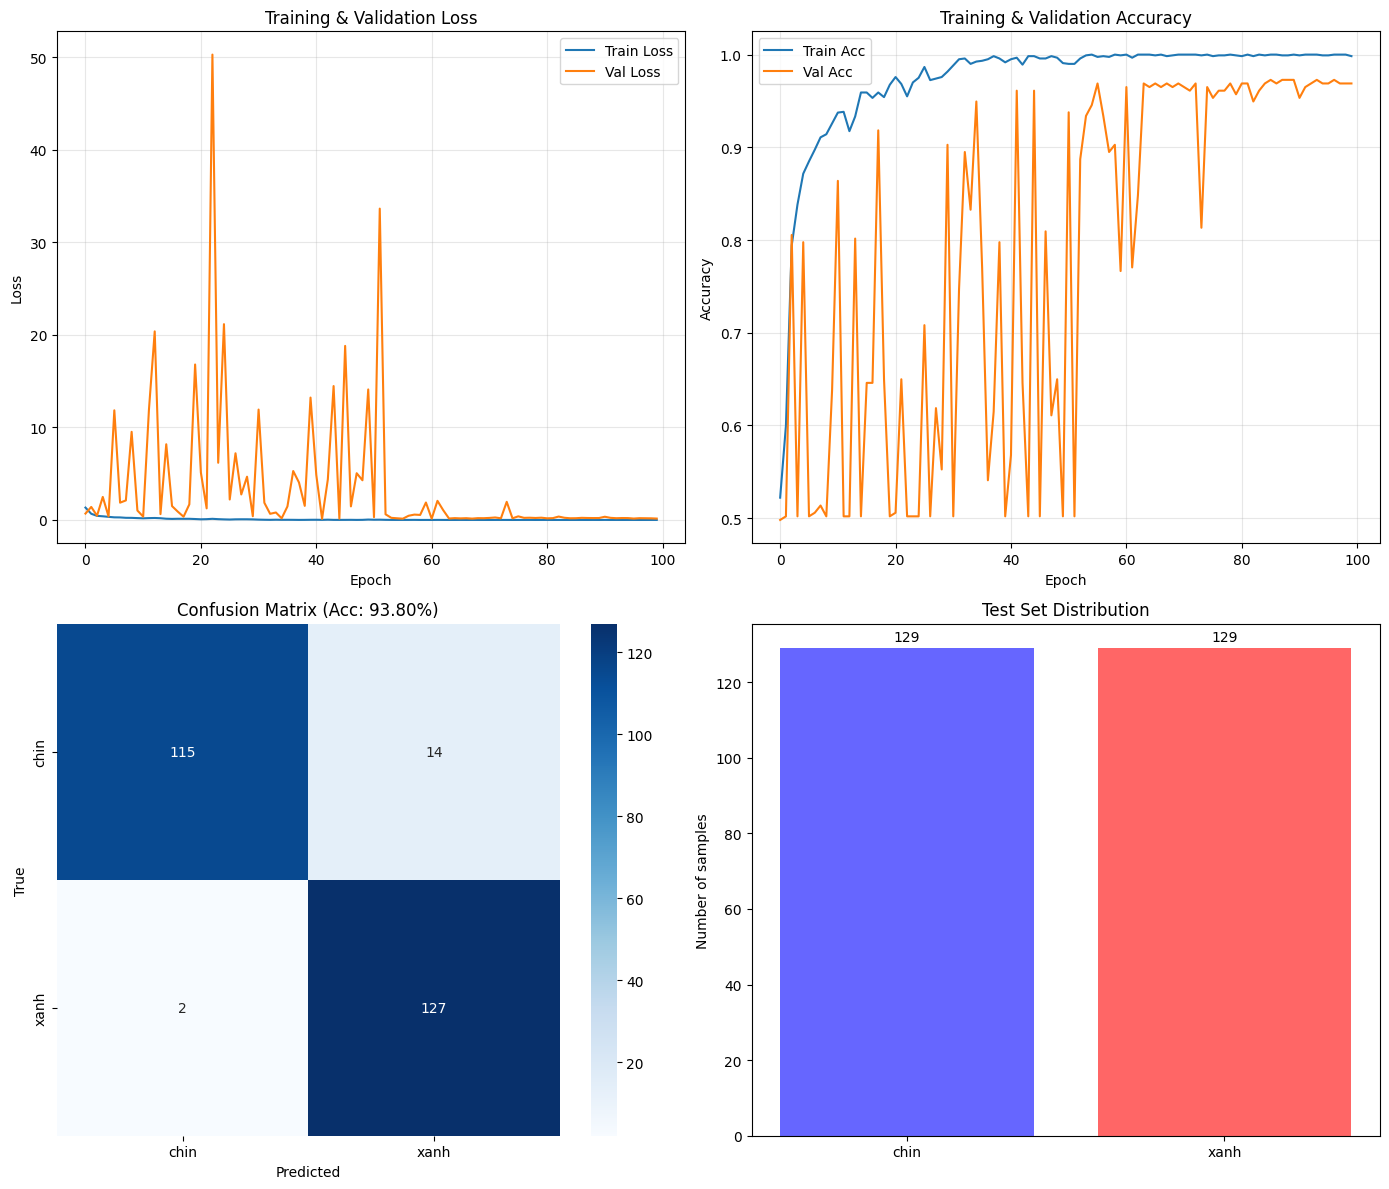


✅ DONE!


In [18]:
# === ĐÁNH GIÁ TRÊN TEST ===
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for batch_X, batch_y in test_loader:
        batch_X = batch_X.to(device)
        output = model(batch_X)
        _, predicted = torch.max(output, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(batch_y.numpy())

# === KẾT QUẢ ===
test_acc = accuracy_score(all_labels, all_preds)
print(f"\n🎯 Test Accuracy: {test_acc:.4f}")
print("\n📋 Classification Report:")
print(classification_report(all_labels, all_preds, target_names=['chin', 'xanh']))
plot_results(history, all_labels, all_preds)

print("\n✅ DONE!")



CLASS STUDENT

In [19]:
class MelStudent(nn.Module):
    def __init__(self, num_classes=2, dropout_rate=0.3):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 24, 3, padding=1),
            nn.BatchNorm2d(24),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(24, 48, 3, padding=1),
            nn.BatchNorm2d(48),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(48, 96, 3, padding=1),
            nn.BatchNorm2d(96),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(96, 192, 3, padding=1),
            nn.BatchNorm2d(192),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        self.pool = nn.AdaptiveAvgPool2d((1, 1))

        self.classifier = nn.Sequential(
            nn.Linear(192, 128),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x
    
#===================================================
teacher = MelCNN(num_classes=2).to(device)

teacher.load_state_dict(
    torch.load(
        'best_model.pth',
        map_location=device
    )
)

teacher.eval()

for param in teacher.parameters():
    param.requires_grad = False
    
#======================================================
student = MelStudent(num_classes=2).to(device)

teacher_params = sum(
    p.numel() for p in teacher.parameters()
)

student_params = sum(
    p.numel() for p in student.parameters()
)

print(f"Teacher parameters: {teacher_params:,}")
print(f"Student parameters: {student_params:,}")

print(
    f"Parameter reduction: "
    f"{(1 - student_params / teacher_params) * 100:.2f}%"
)


#===========================================
def distillation_loss(
    student_logits,
    teacher_logits,
    labels,
    temperature=2.0,
    alpha=0.1   # chỉ số nên tin teacher hay tin nhãn thật
):

    ce_loss = nn.CrossEntropyLoss()(
        student_logits,
        labels
    )

    student_soft = torch.log_softmax(
        student_logits / temperature,
        dim=1
    )

    teacher_soft = torch.softmax(
        teacher_logits / temperature,
        dim=1
    )

    kd_loss = nn.KLDivLoss( reduction='batchmean')(
        student_soft,
        teacher_soft
    )

    kd_loss *= temperature ** 2
    loss = (alpha * ce_loss + (1 - alpha) * kd_loss)

    return loss

Teacher parameters: 8,909,762
Student parameters: 243,986
Parameter reduction: 97.26%


In [20]:
optimizer = optim.Adam(
    student.parameters(),
    lr=0.001,
    weight_decay=1e-4
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=10
)

temperature = 4.0
alpha = 0.5

best_student_acc = -1

history_student = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': []
}

#=========================================================
for epoch in range(100):

    student.train()

    train_loss = 0
    train_correct = 0
    train_total = 0

    for batch_X, batch_y in train_loader:

        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)

        optimizer.zero_grad()

        student_logits = student(batch_X)

        with torch.no_grad():
            teacher_logits = teacher(batch_X)

        loss = distillation_loss(
            student_logits,
            teacher_logits,
            batch_y,
            temperature,
            alpha
        )

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        predicted = torch.argmax(
            student_logits,
            dim=1
        )

        train_correct += (
            predicted == batch_y
        ).sum().item()

        train_total += batch_y.size(0)

    train_loss = train_loss / len(train_loader)
    train_acc = train_correct / train_total


    # Validation

    student.eval()

    val_loss = 0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for batch_X, batch_y in val_loader:

            batch_X = batch_X.to(device)
            batch_y = batch_y.to(device)

            student_logits = student(batch_X)
            teacher_logits = teacher(batch_X)

            loss = distillation_loss(
                student_logits,
                teacher_logits,
                batch_y,
                temperature,
                alpha
            )

            val_loss += loss.item()

            predicted = torch.argmax(
                student_logits,
                dim=1
            )

            val_correct += (
                predicted == batch_y
            ).sum().item()

            val_total += batch_y.size(0)

    val_loss = val_loss / len(val_loader)
    val_acc = val_correct / val_total

    history_student['train_loss'].append(train_loss)
    history_student['train_acc'].append(train_acc)
    history_student['val_loss'].append(val_loss)
    history_student['val_acc'].append(val_acc)

    scheduler.step(val_loss)

    if val_acc > best_student_acc:

        best_student_acc = val_acc

        torch.save(
            student.state_dict(),
            'best_student.pth'
        )

    if (epoch + 1) % 10 == 0:

        print(
            f"Epoch {epoch+1:3d}/100 | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_acc:.4f}"
        )

print(
    f"\nBest Student Val Accuracy: "
    f"{best_student_acc:.4f}"
)


student.load_state_dict(
    torch.load(
        'best_student.pth',
        map_location=device
    )
)

student.eval()

Epoch  10/100 | Train Loss: 1.0488 | Train Acc: 0.9441 | Val Loss: 2.7500 | Val Acc: 0.8405
Epoch  20/100 | Train Loss: 0.6157 | Train Acc: 0.9666 | Val Loss: 45.8289 | Val Acc: 0.5175
Epoch  30/100 | Train Loss: 0.1841 | Train Acc: 0.9942 | Val Loss: 0.8170 | Val Acc: 0.9455
Epoch  40/100 | Train Loss: 0.1254 | Train Acc: 0.9983 | Val Loss: 0.7719 | Val Acc: 0.9416
Epoch  50/100 | Train Loss: 0.0972 | Train Acc: 1.0000 | Val Loss: 14.7759 | Val Acc: 0.6498
Epoch  60/100 | Train Loss: 0.0802 | Train Acc: 1.0000 | Val Loss: 0.6111 | Val Acc: 0.9572
Epoch  70/100 | Train Loss: 0.0741 | Train Acc: 1.0000 | Val Loss: 0.7795 | Val Acc: 0.9494
Epoch  80/100 | Train Loss: 0.0631 | Train Acc: 1.0000 | Val Loss: 0.6362 | Val Acc: 0.9455
Epoch  90/100 | Train Loss: 0.0563 | Train Acc: 1.0000 | Val Loss: 0.6943 | Val Acc: 0.9533
Epoch 100/100 | Train Loss: 0.0541 | Train Acc: 1.0000 | Val Loss: 0.5616 | Val Acc: 0.9494

Best Student Val Accuracy: 0.9572


MelStudent(
  (features): Sequential(
    (0): Conv2d(1, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(24, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(24, 48, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(48, 96, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(96, 192, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(192, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
 

In [21]:
all_preds = []
all_labels = []

with torch.no_grad():

    for batch_X, batch_y in test_loader:

        batch_X = batch_X.to(device)

        output = student(batch_X)

        predicted = torch.argmax(
            output,
            dim=1
        )

        all_preds.extend(
            predicted.cpu().numpy()
        )

        all_labels.extend(
            batch_y.numpy()
        )

test_acc = accuracy_score(
    all_labels,
    all_preds
)

print(f"\nStudent Test Accuracy: {test_acc:.4f}")

print("\nStudent Classification Report:")

print(
    classification_report(
        all_labels,
        all_preds,
        target_names=['chin', 'xanh'],
        digits=4
    )
)


Student Test Accuracy: 0.9302

Student Classification Report:
              precision    recall  f1-score   support

        chin     0.9587    0.8992    0.9280       129
        xanh     0.9051    0.9612    0.9323       129

    accuracy                         0.9302       258
   macro avg     0.9319    0.9302    0.9302       258
weighted avg     0.9319    0.9302    0.9302       258



Do esp32 ở đây cần giảm về mặt kiến trúc thay vì chỉ cần giảm về mặt trọng số, nên ở đây chúng ta chọn prunning theo cấu trúc

In [22]:
# ==================== STRUCTURED PRUNING ====================

def structured_pruning(model, prune_ratio=0.2):
    convs = [m for m in model.features if isinstance(m, nn.Conv2d)]
    bns = [m for m in model.features if isinstance(m, nn.BatchNorm2d)]

    # Số channel sau pruning
    new_channels = [
        int(conv.out_channels * (1 - prune_ratio))
        for conv in convs
    ]

    # Chọn channel quan trọng nhất
    keep = []

    for conv, n in zip(convs, new_channels):
        importance = conv.weight.detach().abs().sum(dim=(1, 2, 3))
        idx = torch.topk(importance, n).indices.sort().values
        keep.append(idx)

    c1, c2, c3, c4 = new_channels

    # Tạo architecture nhỏ hơn
    pruned = MelStudent()

    pruned.features[0] = nn.Conv2d(1, c1, 3, padding=1)
    pruned.features[1] = nn.BatchNorm2d(c1)

    pruned.features[4] = nn.Conv2d(c1, c2, 3, padding=1)
    pruned.features[5] = nn.BatchNorm2d(c2)

    pruned.features[8] = nn.Conv2d(c2, c3, 3, padding=1)
    pruned.features[9] = nn.BatchNorm2d(c3)

    pruned.features[12] = nn.Conv2d(c3, c4, 3, padding=1)
    pruned.features[13] = nn.BatchNorm2d(c4)

    pruned.classifier[0] = nn.Linear(c4, 128)

    pruned = pruned.to(device)

    new_convs = [m for m in pruned.features if isinstance(m, nn.Conv2d)]
    new_bns = [m for m in pruned.features if isinstance(m, nn.BatchNorm2d)]

    # Copy weight từ Student gốc sang model pruned
    with torch.no_grad():

        for i in range(4):
            in_idx = keep[i - 1] if i > 0 else torch.arange(1)
            out_idx = keep[i]

            new_convs[i].weight.copy_(
                convs[i].weight[out_idx][:, in_idx]
            )
            new_convs[i].bias.copy_(
                convs[i].bias[out_idx]
            )

            new_bns[i].weight.copy_(
                bns[i].weight[out_idx]
            )
            new_bns[i].bias.copy_(
                bns[i].bias[out_idx]
            )
            new_bns[i].running_mean.copy_(
                bns[i].running_mean[out_idx]
            )
            new_bns[i].running_var.copy_(
                bns[i].running_var[out_idx]
            )

        # Copy classifier
        pruned.classifier[0].weight.copy_(
            model.classifier[0].weight[:, keep[-1]]
        )
        pruned.classifier[0].bias.copy_(
            model.classifier[0].bias
        )

        pruned.classifier[3].weight.copy_(
            model.classifier[3].weight
        )
        pruned.classifier[3].bias.copy_(
            model.classifier[3].bias
        )

    return pruned


# ==================== LOAD STUDENT ====================

student = MelStudent().to(device)

student.load_state_dict(
    torch.load(
        "best_student.pth",
        map_location=device
    )
)

# ==================== PRUNING ====================

pruned_student = structured_pruning(
    student,
    prune_ratio=0.2
)

# ==================== SAVE ====================

torch.save(
    pruned_student.state_dict(),
    "pruned_student.pth"
)

# ==================== CHECK ====================

original_params = sum(
    p.numel() for p in student.parameters()
)

pruned_params = sum(
    p.numel() for p in pruned_student.parameters()
)

reduction = (
    1 - pruned_params / original_params
) * 100

print("Original channels : 1 → 24 → 48 → 96 → 192")
print("Pruned channels   : 1 → 19 → 38 → 76 → 153")
print(f"Original params   : {original_params:,}")
print(f"Pruned params     : {pruned_params:,}")
print(f"Parameter reduction: {reduction:.2f}%")
print("Saved: pruned_student.pth")

Original channels : 1 → 24 → 48 → 96 → 192
Pruned channels   : 1 → 19 → 38 → 76 → 153
Original params   : 243,986
Pruned params     : 158,141
Parameter reduction: 35.18%
Saved: pruned_student.pth


In [23]:
# ==================== FINE-TUNING PRUNED STUDENT ====================

import torch.optim as optim
from sklearn.metrics import accuracy_score, f1_score, recall_score

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    pruned_student.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=3
)

epochs = 15
best_f1 = 0.0

for epoch in range(epochs):

    # ---------- Train ----------
    pruned_student.train()
    train_loss = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = pruned_student(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    # ---------- Validation ----------
    pruned_student.eval()

    val_preds = []
    val_labels = []
    val_loss = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = pruned_student(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()

            preds = outputs.argmax(dim=1)

            val_preds.extend(preds.cpu().numpy())
            val_labels.extend(labels.cpu().numpy())

    val_loss /= len(val_loader)

    val_acc = accuracy_score(val_labels, val_preds)
    val_f1 = f1_score(val_labels, val_preds, average="macro")
    val_recall = recall_score(val_labels, val_preds, average=None)

    scheduler.step(val_f1)

    if val_f1 > best_f1:
        best_f1 = val_f1

        torch.save(
            pruned_student.state_dict(),
            "best_pruned_student.pth"
        )

    print(
        f"Epoch [{epoch+1:02d}/{epochs}] "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f} | "
        f"Val Macro F1: {val_f1:.4f} | "
        f"Chin Recall: {val_recall[0]:.4f}"
    )

print("\nBest Val Macro F1:", best_f1)
print("Saved: best_pruned_student.pth")

Epoch [01/15] Train Loss: 0.1553 | Val Loss: 0.3874 | Val Acc: 0.9144 | Val Macro F1: 0.9140 | Chin Recall: 0.8450
Epoch [02/15] Train Loss: 0.0090 | Val Loss: 0.3062 | Val Acc: 0.9261 | Val Macro F1: 0.9260 | Chin Recall: 0.9612
Epoch [03/15] Train Loss: 0.0145 | Val Loss: 0.7250 | Val Acc: 0.8677 | Val Macro F1: 0.8660 | Chin Recall: 0.9767
Epoch [04/15] Train Loss: 0.0262 | Val Loss: 0.2105 | Val Acc: 0.9455 | Val Macro F1: 0.9455 | Chin Recall: 0.9457
Epoch [05/15] Train Loss: 0.0089 | Val Loss: 0.3080 | Val Acc: 0.9183 | Val Macro F1: 0.9182 | Chin Recall: 0.9457
Epoch [06/15] Train Loss: 0.0062 | Val Loss: 0.2675 | Val Acc: 0.9416 | Val Macro F1: 0.9416 | Chin Recall: 0.9380
Epoch [07/15] Train Loss: 0.0047 | Val Loss: 0.2737 | Val Acc: 0.9416 | Val Macro F1: 0.9416 | Chin Recall: 0.9380
Epoch [08/15] Train Loss: 0.0024 | Val Loss: 0.2398 | Val Acc: 0.9455 | Val Macro F1: 0.9455 | Chin Recall: 0.9380
Epoch [09/15] Train Loss: 0.0046 | Val Loss: 0.2306 | Val Acc: 0.9416 | Val Macr

In [24]:
# ==================== TEST ====================

from sklearn.metrics import classification_report

pruned_student.load_state_dict(
    torch.load(
        "best_pruned_student.pth",
        map_location=device
    )
)

pruned_student.eval()

test_preds = []
test_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        outputs = pruned_student(images)
        preds = outputs.argmax(dim=1)

        test_preds.extend(preds.cpu().numpy())
        test_labels.extend(labels.numpy())

print(classification_report(
    test_labels,
    test_preds,
    target_names=["chin", "xanh"],
    digits=4
))

              precision    recall  f1-score   support

        chin     0.9444    0.9225    0.9333       129
        xanh     0.9242    0.9457    0.9349       129

    accuracy                         0.9341       258
   macro avg     0.9343    0.9341    0.9341       258
weighted avg     0.9343    0.9341    0.9341       258



QUANTIZATION

In [25]:
import torch
import torch.nn as nn
import torch.ao.quantization as tq
from sklearn.metrics import accuracy_score, classification_report

# =========================================================
# 1. Quantization backend
# =========================================================

torch.backends.quantized.engine = "fbgemm"

print("Quantization backend:", torch.backends.quantized.engine)


# =========================================================
# 2. Create pruned Student model
# =========================================================

model = MelStudent()

model.features[0] = nn.Conv2d(
    1, 19, 3, padding=1
)
model.features[1] = nn.BatchNorm2d(19)

model.features[4] = nn.Conv2d(
    19, 38, 3, padding=1
)
model.features[5] = nn.BatchNorm2d(38)

model.features[8] = nn.Conv2d(
    38, 76, 3, padding=1
)
model.features[9] = nn.BatchNorm2d(76)

model.features[12] = nn.Conv2d(
    76, 153, 3, padding=1
)
model.features[13] = nn.BatchNorm2d(153)

model.classifier[0] = nn.Linear(
    153, 128
)

model.load_state_dict(
    torch.load(
        "best_pruned_student.pth",
        map_location="cpu"
    )
)

model.eval()

print("\nLoaded pruned model")
print(
    "Parameters:",
    sum(p.numel() for p in model.parameters())
)


# =========================================================
# 3. Add QuantStub / DeQuantStub
# =========================================================

class QuantizedMelStudent(nn.Module):

    def __init__(self, model):
        super().__init__()

        self.quant = tq.QuantStub()

        self.features = model.features
        self.pool = model.pool
        self.classifier = model.classifier

        self.dequant = tq.DeQuantStub()

    def forward(self, x):

        x = self.quant(x)

        x = self.features(x)

        x = self.pool(x)

        x = torch.flatten(x, 1)

        x = self.classifier(x)

        x = self.dequant(x)

        return x


model = QuantizedMelStudent(model)

model.eval()


# =========================================================
# 4. Fuse Conv + BN + ReLU
# =========================================================

for i in [0, 4, 8, 12]:

    tq.fuse_modules(
        model.features,
        [str(i), str(i + 1), str(i + 2)],
        inplace=True
    )

model.eval()

print("\nFusion completed.")


# =========================================================
# 5. Static Quantization configuration
# =========================================================

model.qconfig = tq.get_default_qconfig("fbgemm")

print("\nQuantization config:")
print(model.qconfig)


# =========================================================
# 6. Prepare
# =========================================================

tq.prepare(
    model,
    inplace=True
)

print("\nModel prepared.")


# =========================================================
# 7. Calibration
# =========================================================

print("\nCalibrating...")

model.eval()

with torch.no_grad():

    for images, _ in train_loader:

        images = images.cpu()

        model(images)

print("Calibration completed.")


# =========================================================
# 8. Convert FP32 -> INT8
# =========================================================

quantized_model = tq.convert(
    model,
    inplace=False
)

quantized_model.eval()

print("\nINT8 conversion completed.")


# =========================================================
# 9. Test INT8 model
# =========================================================

y_true = []
y_pred = []

print("\nTesting INT8 model...")

with torch.no_grad():

    for images, labels in test_loader:

        images = images.cpu()

        outputs = quantized_model(images)

        predictions = outputs.argmax(dim=1)

        y_true.extend(
            labels.numpy()
        )

        y_pred.extend(
            predictions.numpy()
        )


# =========================================================
# 10. Results
# =========================================================

accuracy = accuracy_score(
    y_true,
    y_pred
)

print("\n===================================")
print("        INT8 QUANTIZATION")
print("===================================")

print(
    f"Accuracy: {accuracy:.4f}"
)

print()

print(
    classification_report(
        y_true,
        y_pred,
        target_names=[
            "chin",
            "xanh"
        ],
        digits=4
    )
)


# =========================================================
# 11. Save
# =========================================================

torch.save(
    quantized_model.state_dict(),
    "pruned_student_int8.pth"
)

print(
    "\nSaved: pruned_student_int8.pth"
)

Quantization backend: fbgemm

Loaded pruned model
Parameters: 158141

Fusion completed.

Quantization config:
QConfig(activation=functools.partial(<class 'torch.ao.quantization.observer.HistogramObserver'>, reduce_range=True){}, weight=functools.partial(<class 'torch.ao.quantization.observer.PerChannelMinMaxObserver'>, dtype=torch.qint8, qscheme=torch.per_channel_symmetric){})

Model prepared.

Calibrating...


/tmp/ipykernel_116306/562910553.py:131: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  tq.prepare(
/home/nghung/anaconda3/envs/Duration/lib/python3.10/site-packages/torch/ao/quantization/observer.py:1039: UserWarning: Please use quant_min and quant_max to specify the range for observers.                     reduce_range will be deprecated in a future release of PyTorch.
 

Calibration completed.

INT8 conversion completed.

Testing INT8 model...


/tmp/ipykernel_116306/562910553.py:162: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  quantized_model = tq.convert(



        INT8 QUANTIZATION
Accuracy: 0.9070

              precision    recall  f1-score   support

        chin     0.9646    0.8450    0.9008       129
        xanh     0.8621    0.9690    0.9124       129

    accuracy                         0.9070       258
   macro avg     0.9133    0.9070    0.9066       258
weighted avg     0.9133    0.9070    0.9066       258


Saved: pruned_student_int8.pth
